In [ ]:
import os
import sys
os.chdir('/zhome/71/c/146676/texture_tomography')
sys.path.append('/zhome/71/c/146676/texture_tomography/package/odf_mumott')
import h5py
import numpy as np

import matplotlib.pyplot as plt
from pole_figure_geometry import GeometryContainerM
from odftt.texture import grids, odfs

# Import your lattice functions
from package.utils.lattice import cubic, tetragonal, orthorhombic, hexagonal, trigonal_rhombohedral, monoclinic, triclinic
from package.utils.coordinates import get_probed_coordinates
import argparse
import yaml
from scipy.spatial.transform import Rotation as R

from package.cil_addons.create_pfo_matrix import pfmatrix_eval_gpu, build_pf_program
import pyopencl as cl
import pyopencl.array as clarray


# Resolve to absolute path if relative
config_path = '/zhome/71/c/146676/texture_tomography/configs/aluminum_config_small.yaml'
if not os.path.isabs(config_path):
    # Resolve relative to the current script’s directory
    script_dir = os.path.dirname(os.path.abspath(__file__))
    config_path = os.path.join(script_dir, config_path)

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

pad = cfg['pad']
center = cfg['center']
pixel_size = cfg['pixel_size']
detector_distance = cfg['detector_distance']
N_theta = cfg['N_theta']
min_two_theta = cfg['min_two_theta']
N_workers = cfg['N_workers_integration']
factor = cfg['factor_integration']
N_chi = cfg['N_chi']
N_rot = cfg['N_rot']
grid_resolution_parameter = cfg['grid_resolution_parameter']
kernel_sigma = cfg['kernel_sigma']
peak_width = cfg['peak_width']
wavelength_kev = cfg['wavelength']
wavelength_angstrom = 12.398/wavelength_kev
cif_path = cfg["cif_path"]
reflections_folder = cfg["reflections_folder"]
output_file = cfg['B_matrix_path']
j_direction_0 = np.array(cfg['j_direction_0'])
k_direction_0 = np.array(cfg['k_direction_0'])
p_direction_0 = np.array(cfg['p_direction_0'])
detector_direction_origin = np.array(cfg['detector_direction_origin'])
detector_direction_positive_90 = np.array(cfg['detector_direction_positive_90'])

max_rad = 1475 // 2 + center[1] + pad 
r_max = pixel_size*max_rad
max_two_theta = np.sin(r_max/detector_distance)
two_thetas = np.linspace(min_two_theta,max_two_theta,N_theta)


# Folder with .h5 files
path_h5 = os.path.join(cif_path, reflections_folder)







# === Helper: map crystal system name to lattice constructor ===
def lattice_from_system(crystal_system, a, b, c, alpha, beta, gamma):
    crystal_system = crystal_system.lower()
    if "cubic" in crystal_system:
        A, B = cubic(a)
    elif "tetragonal" in crystal_system:
        A, B = tetragonal(a, c)
    elif "orthorhombic" in crystal_system:
        A, B = orthorhombic(a, b, c)
    elif "hexagonal" in crystal_system:
        A, B = hexagonal(a, c)
    elif "trigonal" in crystal_system or "rhombohedral" in crystal_system:
        A, B = trigonal_rhombohedral(a, alpha)
    elif "monoclinic" in crystal_system:
        A, B = monoclinic(a, b, c, beta)
    elif "triclinic" in crystal_system:
        A, B = triclinic(a, b, c, alpha, beta, gamma)
    else:
        raise ValueError(f"Unknown crystal system: {crystal_system}")
    return A, B


# === Loop through all h5 files ===
h5_files = sorted([f for f in os.listdir(path_h5) if f.endswith(".h5")])

B_matrices = []
hkl_lists = []
intensities_lists = []
two_theta_lists = []
d_lists = []
multiplicity_lists = []
crystal_systems = []
space_groups = []

materials = []  # <-- new addition

for f_name in h5_files:
    full_path = os.path.join(path_h5, f_name)
    with h5py.File(full_path, "r") as f:
        # Load attributes
        a = float(f.attrs["a"])
        b = float(f.attrs["b"])
        c = float(f.attrs["c"])
        alpha = float(f.attrs["alpha"])
        beta = float(f.attrs["beta"])
        gamma = float(f.attrs["gamma"])

        space_group_info = f.attrs["space_group"]
        crystal_system = space_group_info.split(",")[-1].strip().lower()

        # Construct reciprocal lattice
        _, B = lattice_from_system(crystal_system, a, b, c, alpha, beta, gamma)

        # Load datasets
        hkls = [tuple(map(int, h)) for h in f["hkl_list"][:]]
        intensities = np.array(f["intensity_list"][:])
        two_theta = np.array(f["two_theta_list"][:])
        d_vals = np.array(f["d_list"][:])
        multiplicity = np.array(f["multiplicity_list"][:])

        # === Keep old variables ===
        B_matrices.append(B)
        hkl_lists.append(hkls)
        intensities_lists.append(intensities)
        two_theta_lists.append(two_theta)
        d_lists.append(d_vals)
        multiplicity_lists.append(multiplicity)
        crystal_systems.append(crystal_system)
        space_groups.append(space_group_info)

        # === Add to materials ===
        materials.append({
            "file": f_name,
            "system": crystal_system,
            "space_group": space_group_info,
            "B": B,
            "hkl": hkls,
            "intensity": intensities,
            "two_theta": two_theta,
            "d": d_vals,
            "mult": multiplicity,
            "a": a, "b": b, "c": c,
            "alpha": alpha, "beta": beta, "gamma": gamma
        })

N_mat = len(h5_files)

print(f"Loaded {N_mat} materials.")
print(f"Example B-matrix:\n{B_matrices[0]}")
print(f"Example first 5 HKLs: {hkl_lists[0][:5]}")
print(f"Example first 5 Intensities: {intensities_lists[0][:5]}")
print(f"Example crystal system: {materials[0]['system']}")



def hkil_to_hkl(hkil):
    """Convert 4-index (h,k,i,l) to 3-index (h',k',l') for hex/trigonal."""
    h, k, i, l = hkil
    h3 = (2*h + k) / 3
    k3 = (h + 2*k) / 3
    return np.array([h3, k3, l])


h_vectors_list = []
two_theta_peaks_list = []

for idx_mat in range(N_mat):

    h_vectors = []
    for hkl in hkl_lists[idx_mat]:
        if len(hkl) == 4:
            h_vec = B_matrices[idx_mat] @ hkil_to_hkl(hkl)
        else:
            h_vec = B_matrices[idx_mat] @ np.array(hkl)
        
        h_vectors.append(h_vec)

    h_vectors_list.append(h_vectors)

    two_theta_peaks = []
    for idx_miller in range(len(hkl_lists[idx_mat])):
        two_theta_peak = 2*np.arcsin(np.linalg.norm(h_vectors[idx_miller])/(4*np.pi)*wavelength_angstrom)
        two_theta_peaks.append(two_theta_peak)
    two_theta_peaks = np.stack(two_theta_peaks)
    two_theta_peaks_list.append(two_theta_peaks)



angles = np.linspace(0, 2*np.pi, N_rot, endpoint=False)
print('Sampling full rotation!!')

# --- Helper: rotation matrix around z-axis ---
def rotation_matrix_z(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ], dtype=float)



# --- Build nested projection dictionary ---
projections = {}
for i, theta in enumerate(angles):
    rotvec = theta * k_direction_0 / np.linalg.norm(k_direction_0)
    projections[f"{i}"] = {
        "rotation_matrix": R.from_rotvec(rotvec).as_matrix()
    }


# --- Define direction vectors (easy to customize) ---
detector_angles = np.linspace(0, 2*np.pi,N_chi, endpoint=False)
geom_dict = {
    "projections": projections,
    "p_direction_0": p_direction_0,
    "j_direction_0": j_direction_0,
    "k_direction_0": k_direction_0,
    "detector_direction_origin": detector_direction_origin,
    "detector_direction_positive_90": detector_direction_positive_90,
    "detector_angles": detector_angles
}
N_peaks = len(two_theta_peaks)
def get_all_probed_coordinates(two_theta_peaks, dictionary):
    coordinates = []
    for idx_two_theta in range(len(two_theta_peaks)):
        # --- Define rotation angles ---

        two_theta = np.array([two_theta_peaks[idx_two_theta]])  # placeholder for scattering angle
        dictionary["two_theta"] = two_theta

        # --- Example usage ---
        geom = GeometryContainerM(dictionary=dictionary, data_type='dictionary').geometry
        coords = get_probed_coordinates(geom)[:, :, 0, :]
        coordinates.append(coords)

    coordinates = np.stack(coordinates, axis=-1)

    # Transpose coordinates to a format matching the two other arrays
    coordinates = coordinates.transpose((0, 1, 3, 2))[:, np.newaxis, np.newaxis, :, :]

    return coordinates

coordinates_list = []

for i in range(N_mat):
    coordinates = get_all_probed_coordinates(two_theta_peaks_list[i], geom_dict)
    coordinates_list.append(coordinates)
    print('coordinate size',np.product(coordinates.shape)/1e6)
    print(coordinates.shape)


# Collect 2θ values for each material
two_theta_lists = []

# Sort files for reproducible order
h5_files = sorted([f for f in os.listdir(path_h5) if f.endswith(".h5")])

for f_name in h5_files:
    full_path = os.path.join(path_h5, f_name)
    with h5py.File(full_path, "r") as f:
        # Load the two_theta_list dataset as a numpy array
        two_theta = np.array(f["two_theta_list"][:])
        two_theta_lists.append(two_theta)



from odftt.texture import grids, odfs, point_groups

# Map crystal systems to point group definitions
point_group_map = {
    "triclinic": point_groups.trivial,
    "monoclinic": point_groups.cyclic_2,
    "orthorhombic": point_groups.orthorhombic,
    "tetragonal": point_groups.tetragonal,
    "trigonal": point_groups.trigonal,    # or point_groups.cyclic_3
    "hexagonal": point_groups.hexagonal,
    "cubic": point_groups.cubic,
}

grid_list = []
odf_list = []

for m in materials:
    crystal_system = m["system"].lower()

    if crystal_system not in point_group_map:
        raise ValueError(f"Unknown crystal system: {crystal_system}")

    pg = point_group_map[crystal_system]

    grid = grids.hopf_grid(grid_resolution_parameter, pg)
    odf = odfs.GaussianRBF(grid, pg, kernel_sigma)

    grid_list.append(grid)
    odf_list.append(odf)

print(f"Generated grids and ODFs for {len(grid_list)} materials.")


#### Make this automatic!!!
K_list = np.array([odf_list[i].n_modes for i in range(N_mat)])
B_matrices_size = np.sum(K_list)*N_theta*N_chi*N_rot
print('The size of the B_matrices (after convolution) is ', B_matrices_size*4/1e9, 'GB')

N_peaks_list = np.array([len(two_theta_peaks_list[i]) for i in range(N_mat)])


ctx = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prg = build_pf_program(ctx)

coords_cpu = np.squeeze(coordinates_list[0])
coords_cpu = np.asarray(coords_cpu, dtype=np.float32, order="C")
coords_gpu = clarray.to_device(queue, coords_cpu)

sym_ops_cpu = np.stack([gs.as_matrix().reshape(-1) for gs in odf.point_group], axis=0).astype(np.float32)
sym_ops_gpu = clarray.to_device(queue, sym_ops_cpu)
G = sym_ops_cpu.shape[0]

h_vectors = h_vectors_list[0]
h_cpu = np.asarray(h_vectors, dtype=np.float32)
h_cpu /= np.linalg.norm(h_cpu, axis=1, keepdims=True) + 1e-12
h_gpu = clarray.to_device(queue, h_cpu.astype(np.float32))

grid = grid_list[0]
grid_inv_cpu = np.stack([rot.inv().as_matrix().reshape(-1) for rot in grid], axis=0).astype(np.float32)
grid_inv_gpu = clarray.to_device(queue, grid_inv_cpu)

R = coords_cpu.shape[0]   # N_rot
C = coords_cpu.shape[1]   # N_chi
P = coords_cpu.shape[2]   # N_peaks
K = grid_inv_cpu.shape[0] # number of grid points / modes

print(R, C, P, K, G)

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.
Loaded 1 materials.
Example B-matrix:
[[1.55156468 0.         0.        ]
 [0.         1.55156468 0.        ]
 [0.         0.         1.55156468]]
Example first 5 HKLs: [(1, 1, 1), (2, 0, 0), (2, 2, 0), (3, 1, 1), (2, 2, 2)]
Example first 5 Intensities: [100.          50.39072863  37.43630564  45.16570767  12.9472642 ]
Example crystal system: cubic
Sampling full rotation!!
coordinate size 0.972
(300, 1, 1, 90, 12, 3)
Generated grids and ODFs for 1 materials.
The size of the B_matrices (after convolution) is  7.2576 GB


300 90 12 672 24


In [33]:
out_gpu = clarray.empty(
    queue,
    (R, K, C, P),
    dtype=np.float32,
    order="C",
)

out_gpu = pfmatrix_eval_gpu(
    queue=queue,
    prg=prg,
    coords_gpu=coords_gpu,
    grid_inv_gpu=grid_inv_gpu,
    sym_ops_gpu=sym_ops_gpu,
    hvecs_gpu=h_gpu,
    R=R,
    K=K,
    C=C,
    P=P,
    G=G,
    sigma=kernel_sigma,
    out_gpu=out_gpu,
)

queue.finish()


In [34]:
B_matrix = out_gpu.get()

(300, 672, 90, 12)


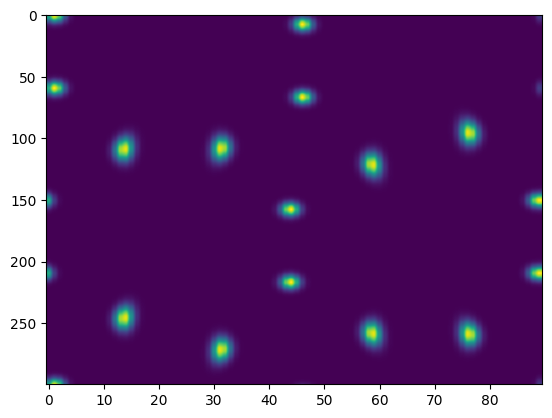

In [37]:
print(B_matrix.shape)
plt.imshow(B_matrix[:,0,:,0], aspect='auto')

In [38]:
N_mat = 1
B_matrix_path = cfg["B_matrix_path"]
with h5py.File(B_matrix_path, 'r') as f:
    K_list = f['K_list'][...]
    material_keys = [k for k in f.keys() if k.endswith('.h5')]


for i_mat in range(N_mat):
    with h5py.File(B_matrix_path, "r") as f:
        g = f[material_keys[i_mat]]
        basis_np = g["data"][...]
        intensity_np = g["intensity"][...]
        peak_positions_np = g["peak_positions"][...]

(300, 672, 90, 12)


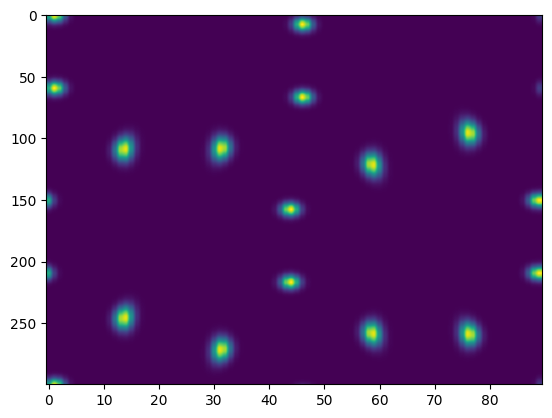

In [43]:
basis_function_arrays = basis_np.reshape((N_rot, K, N_chi, N_peaks))
print(basis_function_arrays.shape)
plt.imshow(basis_function_arrays[:,0,:,0], aspect='auto')

In [46]:
print(np.sum(np.abs(basis_function_arrays - B_matrix))/np.sum(np.abs(B_matrix))) 

6.707841e-06
